In [8]:
import sys
print(sys.executable)

/Users/rahulrg/Quant Trading Project/.venv/bin/python


# Quantitative Trading Strategy Research

## A Comprehensive Study on Predicting Cryptocurrency Returns Using Machine Learning

**Author:** Rahul RG  
**Date:** January 2026

---

### Abstract

This research project explores the development of quantitative trading strategies for cryptocurrency markets, specifically focusing on Bitcoin (BTCUSDT). We investigate multiple approaches including linear regression models and neural networks to predict future price returns. Our methodology involves feature engineering using lagged log returns, model training with PyTorch, and comprehensive backtesting with transaction cost analysis.

### Table of Contents

1. [Introduction and Background](#1-introduction-and-background)
2. [Data Collection and Preprocessing](#2-data-collection-and-preprocessing)
3. [Feature Engineering](#3-feature-engineering)
4. [Method 1: Simple Linear Regression](#4-method-1-simple-linear-regression)
5. [Method 2: Auto-Regressive Linear Model (AR-3)](#5-method-2-auto-regressive-linear-model-ar-3)
6. [Method 3: Non-Linear Neural Network](#6-method-3-non-linear-neural-network)
7. [Model Comparison and Analysis](#7-model-comparison-and-analysis)
8. [Strategy Development](#8-strategy-development)
9. [Backtesting with Transaction Costs](#9-backtesting-with-transaction-costs)
10. [Streaming Implementation](#10-streaming-implementation)
11. [Conclusions](#11-conclusions)

## 1. Introduction and Background

### Research Objectives

The goal of this research is to develop a profitable trading strategy based on machine learning predictions. We aim to:

1. Build ML models that predict future log returns of Bitcoin
2. Use model predictions to generate trading signals
3. Evaluate strategy performance including transaction costs

### Trading Framework

Our trading system follows a simple pipeline:
```
y_hat = model(x)       # Model predicts future return
orders = strategy(y_hat) # Strategy generates orders based on prediction
execute(orders)         # Execute the trades
```

### Why Linear Models?

While neural networks can potentially capture more complex patterns, we favor linear models for trading because:
- **Interpretability**: We can understand what the model has learned
- **Robustness**: Less prone to overfitting on noisy financial data
- **Generalization**: Better performance on out-of-sample data

In [9]:
# Import required libraries
import polars as pl                         # Fast dataframes for financial data
import numpy as np                          # Numerical computing
from datetime import datetime, timedelta    # Date and time operations
import random

# Machine learning libraries
import torch                                # PyTorch framework
import torch.nn as nn                       # Neural network modules
import torch.optim as optim                 # Optimization algorithms

# Our custom modules
import research                             # Research utilities
import models                               # Model definitions
import binance                              # Data download utilities

# Visualization
import altair as alt
import matplotlib.pyplot as plt

# Set random seed for reproducibility
research.set_seed(42)

# Configure Polars display
pl.Config.set_tbl_width_chars(200)
pl.Config.set_fmt_str_lengths(100)
pl.Config.set_tbl_cols(-1)

polars.config.Config

## 2. Data Collection and Preprocessing

We collect historical trade data from Binance and aggregate it into OHLC (Open, High, Low, Close) bars at different time intervals.

In [10]:
# Configuration Parameters
sym = 'BTCUSDT'           # Trading pair
time_interval = '12h'      # Time interval for OHLC bars
max_lags = 4              # Maximum number of lagged features
forecast_horizon = 1       # How many steps ahead to predict
test_size = 0.25          # Proportion of data for testing out of sample testing.

# Annualization factor for Sharpe ratio (crypto trades 24/7, 365 days)
annualized_rate = research.sharpe_annualization_factor(time_interval, 365, 24)
print(f"Annualization factor for {time_interval} bars: {annualized_rate:.2f}")

Annualization factor for 12h bars: 27.02


In [11]:
# Define date range for historical data
start_date = datetime(2024, 10, 29, 0, 0)
end_date = datetime(2025, 12, 31, 0, 0)

# Download data (uncomment if needed)
#binance.download_date_range(sym, start_date, end_date)

# Load pre-downloaded OHLC data
ts = pl.read_csv(f"{sym}_{time_interval}_ohlc.csv", try_parse_dates=True).sort('datetime')
print(f"Loaded {len(ts)} {time_interval} bars from {ts['datetime'][0]} to {ts['datetime'][-1]}")
ts.head(10)

Loaded 692 12h bars from 2024-10-29 00:00:00 to 2025-10-09 12:00:00


datetime,open,high,low,close
datetime[μs],f64,f64,f64,f64
2024-10-29 00:00:00,69939.9,71607.0,69733.0,71440.1
2024-10-29 12:00:00,71440.0,73660.0,70900.0,72739.5
2024-10-30 00:00:00,72739.5,72797.4,71931.1,71995.0
2024-10-30 12:00:00,71994.9,72984.9,71444.2,72349.0
2024-10-31 00:00:00,72349.0,72720.3,72030.5,72213.3
2024-10-31 12:00:00,72213.4,72270.0,69705.0,70321.9
2024-11-01 00:00:00,70321.9,70500.0,68870.4,70024.8
2024-11-01 12:00:00,70024.7,71650.0,68822.5,69495.5
2024-11-02 00:00:00,69495.4,69913.1,69413.0,69602.5


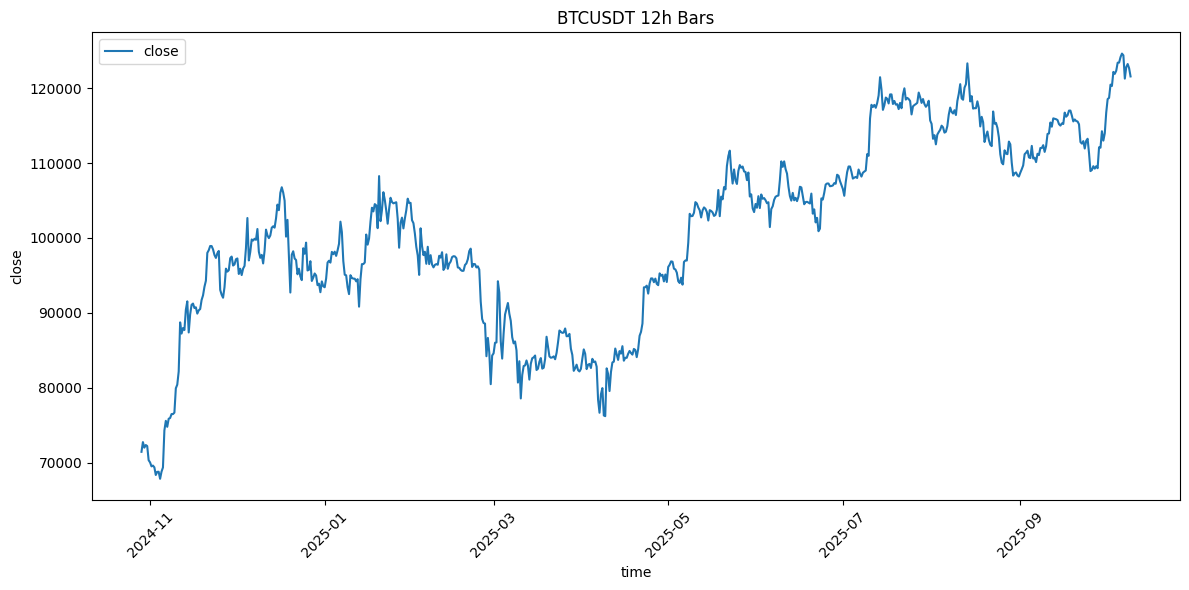

In [12]:
# Visualize the closing price time series
research.plot_static_timeseries(ts, sym, 'close', time_interval)

## 3. Feature Engineering

### Log Returns

We use log returns instead of simple returns because they have several desirable properties:
- Additive over time (log returns can be summed)
- More symmetric distribution
- Better for statistical modeling

**Formula:** $r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$

In [13]:
# Demonstrate log returns calculation
price_time_series = pl.DataFrame({'price': [100.0, 120.0, 100.0]})
price_time_series.with_columns(
    pl.col('price').diff().alias('delta'),
    ((pl.col('price') - pl.col('price').shift()) / pl.col('price').shift()).alias('simple_return'),
    (pl.col('price') / pl.col('price').shift()).log().alias('log_return'),
)

price,delta,simple_return,log_return
f64,f64,f64,f64
100.0,null,null,null
120.0,20.0,0.2,0.182322
100.0,-20.0,-0.166667,-0.182322


In [14]:
# Calculate log returns for our data
target = 'close_log_return'
ts = ts.with_columns(
    (pl.col('close') / pl.col('close').shift(forecast_horizon)).log().alias(target)
)

# Add lagged features for auto-regressive model
ts = research.add_lags(ts, target, max_lags, forecast_horizon)

# Remove rows with null values
ts = ts.drop_nulls()
print(f"After feature engineering: {len(ts)} samples")
ts.head(10)

After feature engineering: 687 samples


datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2024-10-31 12:00:00,72213.4,72270.0,69705.0,70321.9,-0.026541,-0.001877,0.004905,-0.010288,0.018025
2024-11-01 00:00:00,70321.9,70500.0,68870.4,70024.8,-0.004234,-0.026541,-0.001877,0.004905,-0.010288
2024-11-01 12:00:00,70024.7,71650.0,68822.5,69495.5,-0.007587,-0.004234,-0.026541,-0.001877,0.004905
2024-11-02 00:00:00,69495.4,69913.1,69413.0,69602.5,0.001538,-0.007587,-0.004234,-0.026541,-0.001877
2024-11-02 12:00:00,69602.6,69700.0,69022.8,69366.6,-0.003395,0.001538,-0.007587,-0.004234,-0.026541
2024-11-03 00:00:00,69366.6,69393.7,67846.0,68345.4,-0.014831,-0.003395,0.001538,-0.007587,-0.004234
2024-11-03 12:00:00,68345.4,69348.0,67446.6,68762.5,0.006084,-0.014831,-0.003395,0.001538,-0.007587
2024-11-04 00:00:00,68762.5,69495.3,68220.0,68778.0,0.000225,0.006084,-0.014831,-0.003395,0.001538
2024-11-04 12:00:00,68778.1,69243.8,66810.0,67834.3,-0.013816,0.000225,0.006084,-0.014831,-0.003395


In [16]:
# Visualize the distribution of log returns
research.plot_distribution(ts, target, no_bins=100)

alt.Chart(...)

## 4. Method 1: Simple Linear Regression

### Approach

Our first approach uses a simple linear model with only one feature: the previous period's log return (lag 1). This implements a **mean reversion** hypothesis - if the price went up, we expect it to come back down, and vice versa.

**Model:** $\hat{y}_t = w \cdot x_{t-1} + b$

where $x_{t-1}$ is the previous log return.

In [17]:
# Define the Linear Model architecture
class LinearModel(nn.Module):
    def __init__(self, input_features):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(input_features, 1)  # Single output (return prediction)
    
    def forward(self, x):
        return self.linear(x)

# Create model with 1 input feature
model_simple = LinearModel(1)
research.print_model_info(model_simple, "Simple Linear Model (1 feature)")


Simple Linear Model (1 feature)

Architecture:
  LinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

Parameter Count:
  Total parameters:      2
  Trainable parameters:  2



In [18]:
# Prepare data for simple model
features_simple = ['close_log_return_lag_1']

# Split data chronologically
split_idx = int(len(ts) * (1 - test_size))
ts_train = ts[:split_idx]
ts_test = ts[split_idx:]

print(f"Training samples: {len(ts_train)}")
print(f"Test samples: {len(ts_test)}")

# Convert to PyTorch tensors
X_train_simple = torch.tensor(ts_train[features_simple].to_numpy(), dtype=torch.float32)
X_test_simple = torch.tensor(ts_test[features_simple].to_numpy(), dtype=torch.float32)
y_train = torch.tensor(ts_train[target].to_numpy(), dtype=torch.float32).reshape(-1, 1)
y_test = torch.tensor(ts_test[target].to_numpy(), dtype=torch.float32).reshape(-1, 1)

Training samples: 514
Test samples: 172


In [19]:
# Training the simple linear model
model_simple = LinearModel(len(features_simple))

# Hyperparameters
no_epochs = 5000
lr = 0.0005

criterion = nn.MSELoss()
optimizer = optim.Adam(model_simple.parameters(), lr=lr)

print("\nTraining Simple Linear Model...")

for epoch in range(no_epochs):
    # Forward pass
    y_hat = model_simple(X_train_simple)
    loss = criterion(y_hat, y_train)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 1000 == 0:
        print(f"Epoch [{epoch+1}/{no_epochs}], Loss: {loss.item():.6f}")

# Get test predictions
model_simple.eval()
with torch.no_grad():
    y_hat_simple = model_simple(X_test_simple)
    test_loss = criterion(y_hat_simple, y_test)
    print(f"\nTest Loss: {test_loss.item():.6f}")


Training Simple Linear Model...
Epoch [1000/5000], Loss: 0.233733
Epoch [2000/5000], Loss: 0.036239
Epoch [3000/5000], Loss: 0.002182
Epoch [4000/5000], Loss: 0.000370
Epoch [5000/5000], Loss: 0.000351

Test Loss: 0.000105


In [20]:
# Evaluate simple model performance
perf_simple = research.eval_model_performance(y_test, y_hat_simple, features_simple, target, annualized_rate)
print("\n=== Simple Linear Model Performance ===")
for key, value in perf_simple.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


=== Simple Linear Model Performance ===
features: close_log_return_lag_1
target: close_log_return
no_trades: 172
win_rate: 0.5349
avg_win: 0.0078
avg_loss: -0.0072
best_trade: 0.0404
worst_trade: -0.0253
ev: 0.0008
std: 0.0102
total_log_return: 0.1390
compound_return: 1.1492
max_drawdown: -0.0764
equity_trough: -0.0524
equity_peak: 0.1705
sharpe: 2.1493


## 5. Method 2: Auto-Regressive Linear Model (AR-3)

### Approach

Our second approach uses an auto-regressive model with 3 lagged features. This allows the model to capture more complex time-series patterns.

**Model:** $\hat{y}_t = w_1 \cdot x_{t-1} + w_2 \cdot x_{t-2} + w_3 \cdot x_{t-3} + b$

This is the model that showed the best performance in our experiments.

In [21]:
# Features for AR(3) model
features_ar3 = ['close_log_return_lag_1', 'close_log_return_lag_2', 'close_log_return_lag_3']

# Create AR(3) model
model_ar3 = LinearModel(len(features_ar3))
model_ar3.apply(research.init_weights)
research.print_model_info(model_ar3, "AR(3) Linear Model")


AR(3) Linear Model

Architecture:
  LinearModel(
  (linear): Linear(in_features=3, out_features=1, bias=True)
)

Parameter Count:
  Total parameters:      4
  Trainable parameters:  4



In [22]:
# Prepare data for AR(3) model
X_train_ar3 = torch.tensor(ts_train[features_ar3].to_numpy(), dtype=torch.float32)
X_test_ar3 = torch.tensor(ts_test[features_ar3].to_numpy(), dtype=torch.float32)

# Train AR(3) model
optimizer_ar3 = optim.Adam(model_ar3.parameters(), lr=0.0005)
criterion = nn.MSELoss()

print("\nTraining AR(3) Model...")

for epoch in range(no_epochs):
    y_hat = model_ar3(X_train_ar3)
    loss = criterion(y_hat, y_train)
    
    optimizer_ar3.zero_grad()
    loss.backward()
    optimizer_ar3.step()
    
    if (epoch + 1) % 1000 == 0:
        print(f"Epoch [{epoch+1}/{no_epochs}], Loss: {loss.item():.6f}")

# Get test predictions
model_ar3.eval()
with torch.no_grad():
    y_hat_ar3 = model_ar3(X_test_ar3)
    test_loss = criterion(y_hat_ar3, y_test)
    print(f"\nTest Loss: {test_loss.item():.6f}")

# Print learned parameters
print("\nLearned Parameters:")
research.print_model_params(model_ar3)


Training AR(3) Model...
Epoch [1000/5000], Loss: 0.000608
Epoch [2000/5000], Loss: 0.000409
Epoch [3000/5000], Loss: 0.000353
Epoch [4000/5000], Loss: 0.000346
Epoch [5000/5000], Loss: 0.000346

Test Loss: 0.000106

Learned Parameters:
linear.weight:
[[-0.11601903 -0.09912393  0.05908366]]
linear.bias:
[0.00114839]


In [23]:
# Evaluate AR(3) model performance
perf_ar3 = research.eval_model_performance(y_test, y_hat_ar3, features_ar3, target, annualized_rate)
print("\n=== AR(3) Linear Model Performance ===")
for key, value in perf_ar3.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


=== AR(3) Linear Model Performance ===
features: close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
target: close_log_return
no_trades: 172
win_rate: 0.5291
avg_win: 0.0078
avg_loss: -0.0072
best_trade: 0.0404
worst_trade: -0.0253
ev: 0.0007
std: 0.0102
total_log_return: 0.1200
compound_return: 1.1275
max_drawdown: -0.1074
equity_trough: -0.0406
equity_peak: 0.1418
sharpe: 1.8534


### Model Interpretation

The AR(3) model captures mean reversion behavior:
- **Negative weight on lag 1**: If the last period went up, predict going down
- **Smaller weight on lag 2**: Some memory of 2 periods ago
- **Positive bias**: Slight upward drift (crypto's long-term trend)

In [24]:
# Demonstrate mean reversion interpretation
w, b = research.get_linear_params(model_ar3)
print(f"Weights: {w}")
print(f"Bias: {b}")

# Example predictions
def predict_ar3(lag1, lag2, lag3):
    return w[0]*lag1 + w[1]*lag2 + w[2]*lag3 + b

print(f"\nAfter +2% return: predict {predict_ar3(0.02, 0.0, 0.0):.4f} (slightly negative = mean reversion)")
print(f"After -2% return: predict {predict_ar3(-0.02, 0.0, 0.0):.4f} (positive = mean reversion)")
print(f"After flat period: predict {predict_ar3(0.0, 0.0, 0.0):.4f} (slight positive drift)")

Weights: [-0.11601903 -0.09912393  0.05908366]
Bias: 0.001148385345004499

After +2% return: predict -0.0012 (slightly negative = mean reversion)
After -2% return: predict 0.0035 (positive = mean reversion)
After flat period: predict 0.0011 (slight positive drift)


## 6. Method 3: Non-Linear Neural Network

### Approach

For comparison, we also tried a non-linear neural network with a hidden layer and ReLU activation.

**Architecture:**
- Input layer: 3 features
- Hidden layer: 64 neurons with ReLU activation
- Output layer: 1 neuron (predicted return)

In [25]:
# Non-Linear Neural Network Model
class NonLinearModel(nn.Module):
    def __init__(self, input_features, hidden_size=64):
        super(NonLinearModel, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_features, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )
    
    def forward(self, x):
        return self.network(x)

# Create non-linear model
model_nn = NonLinearModel(len(features_ar3), hidden_size=64)
model_nn.apply(research.init_weights)
research.print_model_info(model_nn, "Non-Linear Neural Network")


Non-Linear Neural Network

Architecture:
  NonLinearModel(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

Parameter Count:
  Total parameters:      321
  Trainable parameters:  321



In [26]:
# Compare model complexity
research.print_model_complexity_ratio(model_ar3, "Linear AR(3)", model_nn, "Neural Network")

Complexity Comparsion:
	Neural Network has 80.2x more parameters than Linear AR(3)
	Parametric difference: 317 additional parameters


In [27]:
# Train Neural Network
optimizer_nn = optim.Adam(model_nn.parameters(), lr=0.001)

print("\nTraining Neural Network...")

for epoch in range(no_epochs):
    y_hat = model_nn(X_train_ar3)
    loss = criterion(y_hat, y_train)
    
    optimizer_nn.zero_grad()
    loss.backward()
    optimizer_nn.step()
    
    if (epoch + 1) % 1000 == 0:
        print(f"Epoch [{epoch+1}/{no_epochs}], Loss: {loss.item():.6f}")

# Get test predictions
model_nn.eval()
with torch.no_grad():
    y_hat_nn = model_nn(X_test_ar3)
    test_loss = criterion(y_hat_nn, y_test)
    print(f"\nTest Loss: {test_loss.item():.6f}")


Training Neural Network...
Epoch [1000/5000], Loss: 0.000258
Epoch [2000/5000], Loss: 0.000235
Epoch [3000/5000], Loss: 0.000225
Epoch [4000/5000], Loss: 0.000222
Epoch [5000/5000], Loss: 0.000219

Test Loss: 0.000159


In [28]:
# Evaluate Neural Network performance
perf_nn = research.eval_model_performance(y_test, y_hat_nn, features_ar3, target, annualized_rate)
print("\n=== Neural Network Performance ===")
for key, value in perf_nn.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


=== Neural Network Performance ===
features: close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
target: close_log_return
no_trades: 172
win_rate: 0.4942
avg_win: 0.0063
avg_loss: -0.0087
best_trade: 0.0253
worst_trade: -0.0404
ev: -0.0013
std: 0.0101
total_log_return: -0.2176
compound_return: 0.8045
max_drawdown: -0.3376
equity_trough: -0.2927
equity_peak: 0.0448
sharpe: -3.3789


## 7. Model Comparison and Analysis

### Comparison Summary

In [29]:
# Create comparison dataframe
comparison = pl.DataFrame([
    {'Model': 'Simple Linear (lag1)', 'Features': 1, 'Win Rate': perf_simple['win_rate'], 
     'Sharpe': perf_simple['sharpe'], 'Total Return': perf_simple['compound_return'], 
     'Max Drawdown': perf_simple['max_drawdown']},
    {'Model': 'AR(3) Linear', 'Features': 3, 'Win Rate': perf_ar3['win_rate'], 
     'Sharpe': perf_ar3['sharpe'], 'Total Return': perf_ar3['compound_return'], 
     'Max Drawdown': perf_ar3['max_drawdown']},
    {'Model': 'Neural Network', 'Features': 3, 'Win Rate': perf_nn['win_rate'], 
     'Sharpe': perf_nn['sharpe'], 'Total Return': perf_nn['compound_return'], 
     'Max Drawdown': perf_nn['max_drawdown']},
])

print("=== Model Comparison ===")
comparison

=== Model Comparison ===


Model,Features,Win Rate,Sharpe,Total Return,Max Drawdown
str,i64,f64,f64,f64,f64
"""Simple Linear (lag1)""",1,0.534884,2.149279,1.149178,-0.076382
"""AR(3) Linear""",3,0.52907,1.85341,1.1275,-0.107408
"""Neural Network""",3,0.494186,-3.378912,0.804458,-0.337578


All three Equity curve


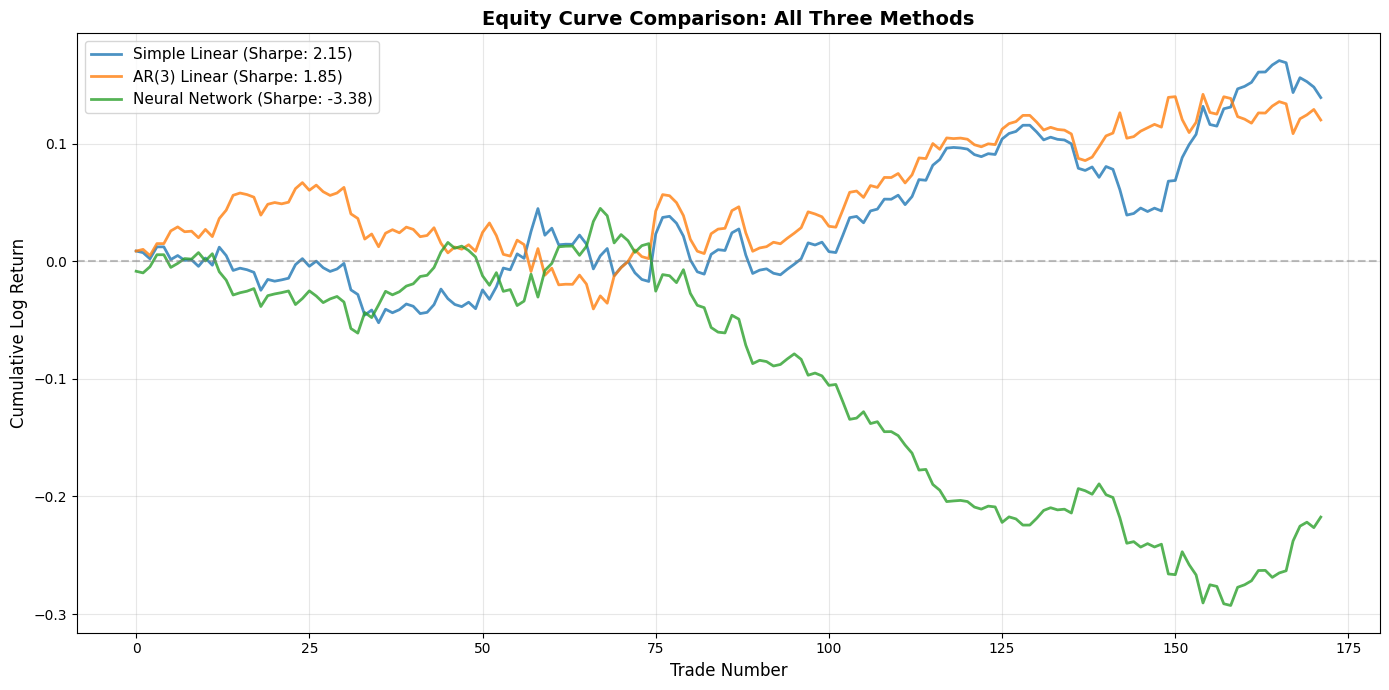


Final Cumulative Log Returns:
  Simple Linear: 0.1390 (14.92%)
  AR(3) Linear:  0.1200 (12.75%)
  Neural Network: -0.2176 (-19.55%)


In [30]:
# Compute equity curves for all three models
trade_results_simple = research.model_trade_results(y_test, y_hat_simple)
trade_results_ar3 = research.model_trade_results(y_test, y_hat_ar3)
trade_results_nn = research.model_trade_results(y_test, y_hat_nn)

# Extract equity curve data
equity_simple = trade_results_simple['equity_curve'].to_numpy()
equity_ar3 = trade_results_ar3['equity_curve'].to_numpy()
equity_nn = trade_results_nn['equity_curve'].to_numpy()

# Plot all three equity curves
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(equity_simple, label=f'Simple Linear (Sharpe: {perf_simple["sharpe"]:.2f})', linewidth=2, alpha=0.8)
plt.plot(equity_ar3, label=f'AR(3) Linear (Sharpe: {perf_ar3["sharpe"]:.2f})', linewidth=2, alpha=0.8)
plt.plot(equity_nn, label=f'Neural Network (Sharpe: {perf_nn["sharpe"]:.2f})', linewidth=2, alpha=0.8)

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Trade Number', fontsize=12)
plt.ylabel('Cumulative Log Return', fontsize=12)
plt.title('Equity Curve Comparison: All Three Methods', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print final returns
print(f'\nFinal Cumulative Log Returns:')
print(f'  Simple Linear: {equity_simple[-1]:.4f} ({(np.exp(equity_simple[-1])-1)*100:.2f}%)')
print(f'  AR(3) Linear:  {equity_ar3[-1]:.4f} ({(np.exp(equity_ar3[-1])-1)*100:.2f}%)')
print(f'  Neural Network: {equity_nn[-1]:.4f} ({(np.exp(equity_nn[-1])-1)*100:.2f}%)')

### Key Findings

1. **Linear models perform comparably to neural networks** for this prediction task
2. **AR(3) with 3 lags captures more information** than single lag model
3. **Linear models are preferred** because they are interpretable and less prone to overfitting

### Interpretability Trade-off

Linear models allow us to understand what's happening:
- We can see the negative weight on lag 1 = mean reversion
- We can calculate exact predictions by hand

Neural networks are "black boxes" - we cannot easily understand why they make certain predictions.

## 8. Strategy Development

### Trading Strategy

Based on our model's predictions, we implement a simple taker strategy:

1. **If model predicts positive return**: Go long (buy)
2. **If model predicts negative return**: Go short (sell)



In [31]:
# Generate trade results from AR(3) model predictions
trade_results = research.model_trade_results(y_test, y_hat_ar3)
trade_results.head(10)

y_pred,y_true,is_won,position,trade_log_return,equity_curve,drawdown_log_return
f32,f32,bool,f32,f32,f32,f32
0.00198,0.008597,true,1.0,0.008597,0.008597,0.0
-0.001729,-0.001385,true,-1.0,0.001385,0.009983,0.0
0.000773,-0.005257,false,1.0,-0.005257,0.004726,-0.005257
0.002404,0.010185,true,1.0,0.010185,0.014911,0.0
0.000406,-0.000009,false,1.0,-0.000009,0.014902,-0.000009
-0.000171,-0.010791,true,-1.0,0.010791,0.025693,0.0
0.003003,0.003417,true,1.0,0.003417,0.02911,0.0
0.001821,-0.004113,false,1.0,-0.004113,0.024997,-0.004113
0.000649,0.000465,true,1.0,0.000465,0.025462,-0.003648


In [32]:
# Plot equity curve
research.plot_column(trade_results, 'equity_curve', title='AR(3) Strategy Equity Curve')

alt.Chart(...)

In [33]:
# Analyze drawdowns
max_drawdown_log = trade_results['drawdown_log_return'].min()
drawdown_pct = np.exp(max_drawdown_log) - 1

print(f"Max Drawdown (log): {max_drawdown_log:.4f}")
print(f"Max Drawdown (%): {drawdown_pct * 100:.2f}%")

Max Drawdown (log): -0.1074
Max Drawdown (%): -10.18%


## 9. Backtesting with Transaction Costs

### Binance Futures Fees

Real trading involves transaction costs:
- **Maker fee**: 0.045% (for limit orders)
- **Taker fee**: 0.045% (for market orders)

We must account for these costs in our backtesting.

In [34]:
# Transaction cost constants (Binance Futures)
MAKER_FEE = 0.000450
TAKER_FEE = 0.000450

# Initial capital and leverage settings
initial_capital = 1000  # USD
leverage = 3  # 3x leverage

print(f"Initial Capital: ${initial_capital}")
print(f"Leverage: {leverage}x")
print(f"Effective Capital: ${initial_capital * leverage}")

Initial Capital: $1000
Leverage: 3x
Effective Capital: $3000


In [35]:
# Load the saved model for strategy execution
model_final = models.LinearModel(3)
model_final.load_state_dict(torch.load('model_weights.pth', weights_only=True))
model_final.eval()

# Show model parameters
print("Final Model Parameters:")
research.print_model_params(model_final)

Final Model Parameters:
linear.weight:
[[-0.10395038 -0.06726477  0.02827305]]
linear.bias:
[0.00067121]


In [36]:
# Prepare test data with model predictions
test_trades = ts_test.clone()
test_trades = research.add_model_predictions(test_trades, model_final, features_ar3)
test_trades.head(10)

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4,close_regular_return,y_hat
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f32
2025-07-16 00:00:00,117738.6,119299.9,117017.1,118755.1,0.008597,0.005349,-0.022844,-0.013743,0.020259,0.008634,0.001263
2025-07-16 12:00:00,118755.1,120100.0,118156.0,118590.7,-0.001385,0.008597,0.005349,-0.022844,-0.013743,-0.001384,-0.001228
2025-07-17 00:00:00,118590.7,119216.4,117663.6,117968.9,-0.005257,-0.001385,0.008597,0.005349,-0.022844,-0.005243,0.000388
2025-07-17 12:00:00,117968.8,120951.5,117412.8,119176.6,0.010185,-0.005257,-0.001385,0.008597,0.005349,0.010237,0.001554
2025-07-18 00:00:00,119176.5,120846.1,118384.6,119175.5,-0.000009,0.010185,-0.005257,-0.001385,0.008597,-0.000009,-0.000073
2025-07-18 12:00:00,119175.5,119519.8,116788.9,117896.4,-0.010791,-0.000009,0.010185,-0.005257,-0.001385,-0.010733,-0.000162
2025-07-19 00:00:00,117896.5,118456.0,117588.0,118300.0,0.003417,-0.010791,-0.000009,0.010185,-0.005257,0.003423,0.002082
2025-07-19 12:00:00,118300.0,118301.4,117245.9,117814.4,-0.004113,0.003417,-0.010791,-0.000009,0.010185,-0.004105,0.001042
2025-07-20 00:00:00,117814.3,118261.6,117618.0,117869.2,0.000465,-0.004113,0.003417,-0.010791,-0.000009,0.000465,0.000564


In [37]:
# Add directional signal and calculate trade log returns
test_trades = test_trades.with_columns(
    pl.col('y_hat').sign().alias('dir_signal'),
).with_columns(
    (pl.col('close_log_return') * pl.col('dir_signal')).alias('trade_log_return'),
).with_columns(
    pl.col('trade_log_return').cum_sum().alias('cum_trade_log_return'),
)

test_trades.head(10)

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4,close_regular_return,y_hat,dir_signal,trade_log_return,cum_trade_log_return
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f64,f64
2025-07-16 00:00:00,117738.6,119299.9,117017.1,118755.1,0.008597,0.005349,-0.022844,-0.013743,0.020259,0.008634,0.001263,1.0,0.008597,0.008597
2025-07-16 12:00:00,118755.1,120100.0,118156.0,118590.7,-0.001385,0.008597,0.005349,-0.022844,-0.013743,-0.001384,-0.001228,-1.0,0.001385,0.009983
2025-07-17 00:00:00,118590.7,119216.4,117663.6,117968.9,-0.005257,-0.001385,0.008597,0.005349,-0.022844,-0.005243,0.000388,1.0,-0.005257,0.004726
2025-07-17 12:00:00,117968.8,120951.5,117412.8,119176.6,0.010185,-0.005257,-0.001385,0.008597,0.005349,0.010237,0.001554,1.0,0.010185,0.014911
2025-07-18 00:00:00,119176.5,120846.1,118384.6,119175.5,-0.000009,0.010185,-0.005257,-0.001385,0.008597,-0.000009,-0.000073,-1.0,0.000009,0.01492
2025-07-18 12:00:00,119175.5,119519.8,116788.9,117896.4,-0.010791,-0.000009,0.010185,-0.005257,-0.001385,-0.010733,-0.000162,-1.0,0.010791,0.025711
2025-07-19 00:00:00,117896.5,118456.0,117588.0,118300.0,0.003417,-0.010791,-0.000009,0.010185,-0.005257,0.003423,0.002082,1.0,0.003417,0.029129
2025-07-19 12:00:00,118300.0,118301.4,117245.9,117814.4,-0.004113,0.003417,-0.010791,-0.000009,0.010185,-0.004105,0.001042,1.0,-0.004113,0.025015
2025-07-20 00:00:00,117814.3,118261.6,117618.0,117869.2,0.000465,-0.004113,0.003417,-0.010791,-0.000009,0.000465,0.000564,1.0,0.000465,0.02548


In [38]:
# Calculate compounding trades with fees
test_trades_with_fees = research.add_compounding_trades(
    test_trades, 
    initial_capital, 
    leverage, 
    MAKER_FEE, 
    TAKER_FEE
)

# Summary statistics
final_equity_gross = test_trades_with_fees['equity_curve_gross'][-1]
final_equity_net = test_trades_with_fees['equity_curve_taker'][-1]

print(f"\n=== Backtesting Results (with {leverage}x leverage) ===")
print(f"Initial Capital: ${initial_capital}")
print(f"Final Equity (Gross): ${final_equity_gross:.2f}")
print(f"Final Equity (Net of fees): ${final_equity_net:.2f}")
print(f"Gross Return: {(final_equity_gross / initial_capital - 1) * 100:.2f}%")
print(f"Net Return: {(final_equity_net / initial_capital - 1) * 100:.2f}%")


=== Backtesting Results (with 3x leverage) ===
Initial Capital: $1000
Final Equity (Gross): $1789.85
Final Equity (Net of fees): $1267.15
Gross Return: 78.98%
Net Return: 26.72%


## 10. Streaming Implementation

### Building Blocks for Live Trading

For production trading systems, we need streaming data structures that can process ticks efficiently.

In [39]:
from abc import ABC, abstractmethod
from typing import Generic, TypeVar, Optional, Deque
from collections import deque

T = TypeVar('T')
R = TypeVar('R')

# Base Tick interface
class Tick(ABC, Generic[T, R]):
    @abstractmethod
    def on_tick(self, val: T) -> R:
        """Handle a new tick and optionally return a result."""
        pass

# Sliding window using deque (O(1) operations)
class DequeWindow(Tick[T, Optional[T]], Generic[T]):
    def __init__(self, n: int):
        self._data: Deque[T] = deque(maxlen=n)

    def on_tick(self, val: T) -> Optional[T]:
        dropped = None
        if self.is_full():
            dropped = self._data[0]
        self._data.append(val)
        return dropped
    
    def is_full(self) -> bool:
        return self._data.maxlen == len(self._data)
    
    def to_numpy(self) -> np.ndarray:
        return np.array(self._data)
    
    def __repr__(self) -> str:
        return f"DequeWindow(capacity={self._data.maxlen}, values={list(self._data)})"

# Streaming Log Return calculator
class LogReturn(Tick[float, Optional[float]]):
    def __init__(self):
        self._prev: Optional[float] = None

    def on_tick(self, val: float) -> Optional[float]:
        if self._prev is not None:
            lr = np.log(val / self._prev)
            self._prev = val
            return lr
        else:
            self._prev = val
            return None

In [40]:
# Demonstrate streaming log return calculation
log_return_stream = LogReturn()

prices = [100, 120, 100, 110]
for p in prices:
    lr = log_return_stream.on_tick(p)
    print(f"Price: {p}, Log Return: {lr}")

Price: 100, Log Return: None
Price: 120, Log Return: 0.1823215567939546
Price: 100, Log Return: -0.1823215567939546
Price: 110, Log Return: 0.09531017980432493


In [41]:
# Streaming AR(3) feature calculator
class AR3Features(Tick[float, Optional[np.ndarray]]):
    def __init__(self):
        self._log_return = LogReturn()
        self._lags = DequeWindow(3)
    
    def on_tick(self, price: float) -> Optional[np.ndarray]:
        lr = self._log_return.on_tick(price)
        if lr is not None:
            self._lags.on_tick(lr)
            if self._lags.is_full():
                # Return features in reverse order (most recent first)
                return self._lags.to_numpy()[::-1]
        return None

# Test AR3 feature streaming
ar3_features = AR3Features()
test_prices = [100, 120, 115, 118, 122, 119]

print("\nStreaming AR(3) Features:")
for p in test_prices:
    features = ar3_features.on_tick(p)
    print(f"Price: {p}, Features: {features}")


Streaming AR(3) Features:
Price: 100, Features: None
Price: 120, Features: None
Price: 115, Features: None
Price: 118, Features: [ 0.0257525  -0.04255961  0.18232156]
Price: 122, Features: [ 0.03333642  0.0257525  -0.04255961]
Price: 119, Features: [-0.02489755  0.03333642  0.0257525 ]


## 11. Conclusions

### Summary of Findings

1. **Mean reversion exists in cryptocurrency markets**: The negative coefficient on lag 1 indicates that price movements tend to reverse.

2. **Simple models can be effective**: A linear AR(3) model captures sufficient information for profitable trading.

3. **Interpretability matters**: Linear models allow us to understand and trust our trading decisions.

4. **Transaction costs are significant**: Strategy performance degrades when accounting for realistic trading fees.

5. **Leverage amplifies returns**: With proper risk management, leverage can improve strategy returns.



In [42]:
# Save the final summary
print("\n" + "="*60)
print("RESEARCH SUMMARY")
print("="*60)
print(f"\nSymbol: {sym}")
print(f"Time Interval: {time_interval}")
print(f"Forecast Horizon: {forecast_horizon} period(s)")
print(f"\nBest Model: AR(3) Linear")
print(f"Features: {features_ar3}")
print(f"\nPerformance Metrics:")
print(f"  - Win Rate: {perf_ar3['win_rate']:.2%}")
print(f"  - Sharpe Ratio: {perf_ar3['sharpe']:.2f}")
print(f"  - Total Return: {(perf_ar3['compound_return'] - 1)*100:.2f}%")
print(f"  - Max Drawdown: {perf_ar3['max_drawdown']*100:.2f}%")
print("="*60)


RESEARCH SUMMARY

Symbol: BTCUSDT
Time Interval: 12h
Forecast Horizon: 1 period(s)

Best Model: AR(3) Linear
Features: ['close_log_return_lag_1', 'close_log_return_lag_2', 'close_log_return_lag_3']

Performance Metrics:
  - Win Rate: 52.91%
  - Sharpe Ratio: 1.85
  - Total Return: 12.75%
  - Max Drawdown: -10.74%
